# Challenge 3: Music Genre Classification

In [1]:
from PIL import Image
import matplotlib.pyplot as plt
image = Image.open("Music.jpg")

## 1. Định nghĩa vấn đề (Define Problem)
+ **Mô tả**:
    + Bộ dữ liệu Music Genre Classification gồm thông tin về các bài hát kèm theo những đặc trưng âm thanh được trích xuất từ Spotify Audio Features. Mỗi bản ghi đại diện cho một bài nhạc với các thuộc tính như độ nhảy (danceability), năng lượng (energy), độ to (loudness), nhịp độ (tempo), thời lượng, độ “sáng” âm thanh (valence), mức độ lời thoại (speechiness)…
    + Mục tiêu: dự đoán thể loại nhạc (Class) của từng bài hát dựa trên các đặc trưng âm thanh.
    + Đây là bài toán phân loại đa lớp (multi-class classification).
+ **Dữ liệu vào (Features)**:
    1. Thông tin nhận dạng
    + Id: Mã định danh của bài hát
    + Artist Name: Tên nghệ sĩ
    + Track Name: Tên bài hát

    2. Đặc trưng âm thanh:
    + Popularity: Độ phổ biến của bài hát (0–100).
    + danceability: Mức độ phù hợp để nhảy (0–1).
    + energy: Mức năng lượng của bài hát (0–1).
    + key: Tông nhạc (0–11).
    + loudness: Độ lớn trung bình của âm thanh (đơn vị dB).
    + mode:
    1 = major
    0 = minor
    + speechiness: Mức độ chứa lời nói (rap có giá trị cao).
    + acousticness: Mức độ acoustic (0–1).
    + instrumentalness: Mức độ instrumental (không lời).
    + liveness: Khả năng được thu live.
    + valence: Mức độ “tươi vui” của âm thanh (0–1).
    + tempo: Nhịp độ (BPM).
    + duration_in min/ms: Thời lượng bài hát (ms).
    + time_signature: Chỉ số nhịp (3, 4,…).
+ **Kết quả**:
    + **Class**: Thể loại nhạc tương ứng của bài hát.
    + Đây là biến phân loại nhiều lớp.

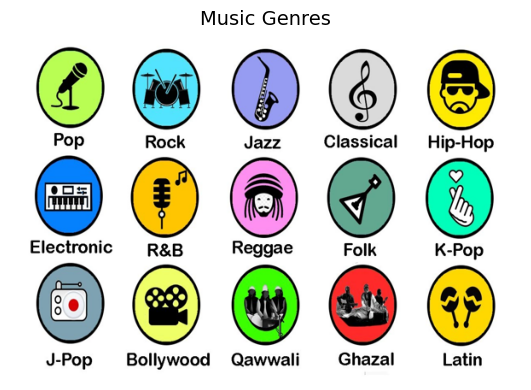

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(image.resize((600, 400)))
ax.axis("off")
ax.set_title("Music Genres", fontsize=14, pad=10)
plt.tight_layout()
plt.show()

## 2. Chuẩn bị vấn đề (Prepare Problem)

### 2.1. Khai báo thư viện (Load Libraries)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import display

import warnings
%matplotlib inline
warnings.filterwarnings("ignore")

### 2.2. Nạp dữ liệu (Load Dataset)

In [4]:
# Load dataset
df_train = pd.read_csv("../../data03/train.csv")
df_test = pd.read_csv("../../data03/test.csv")

## 3. Phân tích khám phá dữ liệu (Exploration Analyze Data - EDA)

### 3.1. Thống kê mô tả (Descriptive Statistics) - Ungraphic Approach

#### (1) **Hiển thị một số thông tin về dữ liệu**

In [5]:
# shape
print(f'+ Shape: {df_train.shape}')
# head, tail
print(f'+ Contents: ')
display.display(df_train.head(5))
display.display(df_train.tail(5))
# info
df_train.info()

+ Shape: (14396, 18)
+ Contents: 


,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,1,Marina Maximilian,Not Afraid,37.0,0.334,0.536,9.0,-6.649,0,0.0381,0.378000,NaN,0.106,0.235,152.429,204947.0,4,9
1,2,The Black Keys,Howlin' for You,67.0,0.725,0.747,11.0,-5.545,1,0.0876,0.027200,0.0468,0.104,0.380,132.921,191956.0,4,6
2,3,Royal & the Serpent,phuck u,NaN,0.584,0.804,7.0,-6.094,1,0.0619,0.000968,0.6350,0.284,0.635,159.953,161037.0,4,10
3,4,Detroit Blues Band,Missing You,12.0,0.515,0.308,NaN,-14.711,1,0.0312,0.907000,0.0213,0.300,0.501,172.472,298093.0,3,2
4,5,Coast Contra,My Lady,48.0,0.565,0.777,6.0,-5.096,0,0.2490,0.183000,NaN,0.211,0.619,88.311,254145.0,4,5


,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
14391,14392,NOISY,I Wish I Was A...,47.0,0.607,0.946,1.0,-2.965,1,0.1500,0.005480,0.000390,0.2780,0.653,120.011,195181.000000,4,10
14392,14393,BLOODSPOT,Deadline Story (feat. Patrick Boos),27.0,0.435,0.951,8.0,-7.475,1,0.0576,0.000005,0.550000,0.0952,0.203,135.034,282043.000000,4,8
14393,14394,Cold Years,Too Far Gone,22.0,0.415,0.941,11.0,-4.300,1,0.0524,0.001810,0.000004,0.3370,0.572,167.978,176529.000000,4,10
14394,14395,The Jaded Hearts Club,Reach Out I'll Be There,37.0,0.493,0.986,1.0,-2.279,1,0.0917,0.000967,0.006620,0.1230,0.567,122.036,186307.000000,4,10
14395,14396,Freddy Fender,Before the Next Teardrop Falls,50.0,0.799,0.345,10.0,-11.520,1,0.0276,0.748000,0.000024,0.1690,0.776,90.417,2.614567,4,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14396 entries, 0 to 14395
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  14396 non-null  int64  
 1   Artist Name         14396 non-null  object 
 2   Track Name          14396 non-null  object 
 3   Popularity          14063 non-null  float64
 4   danceability        14396 non-null  float64
 5   energy              14396 non-null  float64
 6   key                 12787 non-null  float64
 7   loudness            14396 non-null  float64
 8   mode                14396 non-null  int64  
 9   speechiness         14396 non-null  float64
 10  acousticness        14396 non-null  float64
 11  instrumentalness    10855 non-null  float64
 12  liveness            14396 non-null  float64
 13  valence             14396 non-null  float64
 14  tempo               14396 non-null  float64
 15  duration_in min/ms  14396 non-null  float64
 16  time

**Nhận xét**
- Tổng số dòng dữ liệu là 14396.
- Tổng số cột dữ liệu là 18.
- Dữ liệu dùng để phân lớp: cột Class, đại diện cho thể loại nhạc (genre) mà mô hình cần dự đoán.

#### (2) **Kiểm tra tính toàn vẹn của dữ liệu**

In [7]:
# Kiểm tra giá trị thiếu
def isNull(df):
    print("="*5, "Checking Null", "="*5)
    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0]
    if len(null_cols) > 0 :
        display.display(null_cols)
    has_null = df.isnull().sum().any()
    print(f'--> Có giá trị Null: {has_null}')

In [8]:
isNull(df_train)

===== Checking Null =====


Popularity           333
key                 1609
instrumentalness    3541
dtype: int64

--> Có giá trị Null: True


In [9]:
isNull(df_test)

===== Checking Null =====


Popularity           95
key                 405
instrumentalness    836
dtype: int64

--> Có giá trị Null: True


**Nhận xét**:
- Dữ liệu ở tập train có giá trị thiếu ở cột Popularity (333), key (1609), instrumentalness (3541).

- Dữ liệu ở tập test có giá trị thiếu ở cột Popularity (95), key (405), instrumentalness (836).

#### (3) **Các tính chất thống kê trên dữ liệu số**

+ Count, Mean, Standard Deviation, Minimum Value
+ 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

In [10]:
display.display(df_train.describe().T)

,count,mean,std,min,25%,50%,75%,max
Id,14396.0,7198.500000,4155.911573,1.000000,3599.750000,7198.50000,10797.25000,14396.000
Popularity,14063.0,44.525208,17.418940,1.000000,33.000000,44.00000,56.00000,100.000
danceability,14396.0,0.543105,0.165517,0.059600,0.432000,0.54500,0.65800,0.989
energy,14396.0,0.662422,0.235967,0.001210,0.508000,0.69900,0.86100,1.000
key,12787.0,5.953781,3.200013,1.000000,3.000000,6.00000,9.00000,11.000
loudness,14396.0,-7.900852,4.057362,-39.952000,-9.538000,-7.01350,-5.16200,1.342
mode,14396.0,0.640247,0.479944,0.000000,0.000000,1.00000,1.00000,1.000
speechiness,14396.0,0.080181,0.085157,0.022500,0.034800,0.04710,0.08310,0.955
acousticness,14396.0,0.246746,0.310922,0.000000,0.004280,0.08145,0.43225,0.996
instrumentalness,10855.0,0.178129,0.304266,0.000001,0.000088,0.00392,0.20100,0.996


**Nhận xét**:
- Các đặc trưng âm thanh như danceability, energy, speechiness, acousticness, liveness, valence đều có giá trị trung bình trong khoảng 0–1 và độ lệch chuẩn nhỏ -> phân bố dữ liệu khá ổn định và tuân theo chuẩn normalized của Spotify.

- Biến loudness có độ lệch chuẩn lớn và giá trị min rất thấp (–39.95 dB), phản ánh sự khác biệt đáng kể về độ lớn âm thanh giữa các bài hát và khả năng tồn tại ngoại lệ.

- Tempo và duration_in min/ms có phạm vi dao động rất rộng, thể hiện sự đa dạng mạnh về nhịp độ và thời lượng bài hát; đặc biệt duration có độ lệch chuẩn lớn, chỉ ra nhiều bài quá ngắn hoặc quá dài.

- Một số cột có số lượng giá trị thiếu đáng kể như key và instrumentalness cần được xử lý trước khi đưa vào mô hình.

- Các biến dạng nhịp như mode và time_signature có độ lệch chuẩn thấp, chủ yếu tập trung vào các giá trị cố định (mode=1, time_signature=4).

- Biến mục tiêu Class trải dài từ 0 đến 10 -> nhiệm vụ phân loại đa lớp với nhiều thể loại nhạc khác nhau.

#### (4) **Tần số xuất hiện (Distribution) trên dữ liệu phân lớp (Class) và dữ liệu danh mục (Category)**

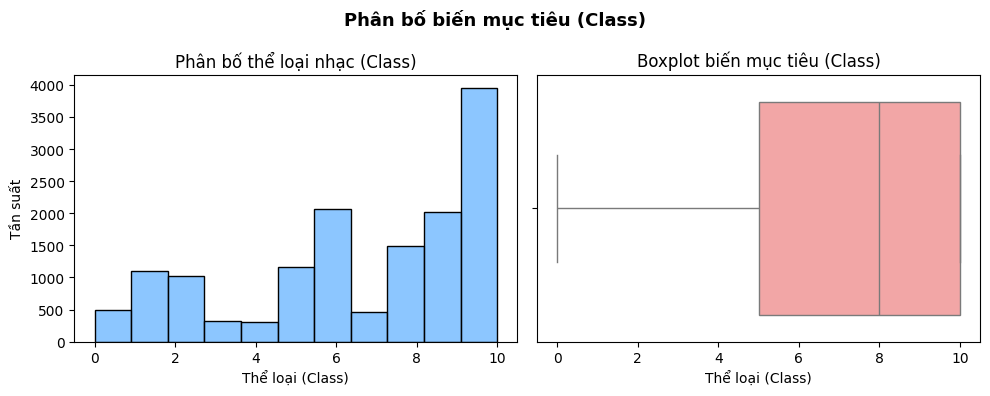

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Biểu đồ phân phối (histplot)
sns.histplot(df_train['Class'], bins=11, kde=False, color='#66b3ff', ax=ax[0])
ax[0].set_title('Phân bố thể loại nhạc (Class)', fontsize=12)
ax[0].set_xlabel('Thể loại (Class)')
ax[0].set_ylabel('Tần suất')

# Biểu đồ Boxplot
sns.boxplot(x=df_train['Class'], color='#ff9999', ax=ax[1])
ax[1].set_title('Boxplot biến mục tiêu (Class)', fontsize=12)
ax[1].set_xlabel('Thể loại (Class)')

plt.suptitle('Phân bố biến mục tiêu (Class)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét**:
- Biểu đồ histogram cho thấy phân phối của biến Class hoàn toàn không đồng đều và mang tính mất cân bằng (imbalanced). Một số thể loại nhạc (đặc biệt là Class 9 và 10) xuất hiện với tần suất rất cao, trong khi các lớp như 0, 3 và 4 có số lượng mẫu rất ít. Phân phối do đó không đối xứng và nghiêng mạnh về phía các class có tần suất lớn.

- Biểu đồ boxplot thể hiện rõ sự phân bố lệch này: phần lớn dữ liệu tập trung ở các lớp lớn (khoảng 7–10), trong khi phần đuôi bên trái kéo dài, phản ánh sự xuất hiện thưa thớt của các class nhỏ -> biến mục tiêu không tuân theo phân phối chuẩn, đồng thời tồn tại sự chênh lệch lớn giữa các nhóm lớp — một yếu tố quan trọng cần xử lý trước khi huấn luyện mô hình phân loại.

In [13]:
# Đếm tần suất giá trị trong từng cột dạng chữ
cat_cols = df_train.select_dtypes(include=['object']).columns.tolist()

for col in cat_cols:
    print(f"--- {col} ---")
    print(df_train[col].value_counts(), "\n")

--- Artist Name ---
Artist Name
Backstreet Boys    58
Westlife           53
Britney Spears     47
Omer Adam          39
Eyal Golan         38
                   ..
BUZZ                1
GRiZ                1
Fitila              1
Hotel Pools         1
Panama              1
Name: count, Length: 7913, dtype: int64 

--- Track Name ---
Track Name
Fire                                       8
Ghost                                      7
Runaway                                    7
Control                                    6
Hurricane                                  6
                                          ..
◊ë◊ê ◊ú◊ô◊î◊†◊ï◊™ - ◊®◊û◊ô◊ß◊°             1
Fuckin With My Head (Mountain Dew Rock)    1
My Lady                                    1
Missing You                                1
phuck u                                    1
Name: count, Length: 12455, dtype: int64 



**Nhận xét**:
- Cột Artist Name có tổng cộng 7,913 nghệ sĩ khác nhau, trong đó phần lớn chỉ xuất hiện 1 lần -> dữ liệu có mức độ phân tán rất cao theo nghệ sĩ. Một số nghệ sĩ xuất hiện nhiều như Backstreet Boys (58), Westlife (53) và Britney Spears (47), nhưng phần này chỉ chiếm tỷ lệ nhỏ cho thấy số lượng bài hát trong dataset không tập trung vào một nhóm nghệ sĩ cố định mà trải rộng trên nhiều nghệ sĩ khác nhau.

- Cột Track Name còn phân tán mạnh hơn với 12,455 tên bài hát khác nhau, phần lớn chỉ xuất hiện 1 lần, thể hiện tính đa dạng rất cao của âm nhạc trong tập dữ liệu. Một số bài hát trùng tên xuất hiện nhiều hơn như Fire (8), Ghost (7), Runaway (7) hay Control (6) tuy nhiên số lượng rất nhỏ so với toàn bộ dataset -> tên bài hát không mang tính lặp lại và khó có giá trị phân biệt cho mô hình nếu không xử lý đặc biệt.

In [15]:
# Xác định cột số và cột phân loại
numeric_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.drop('Class')
categorical_cols = df_train.select_dtypes(include=['object']).columns

print("Cột số:", len(numeric_cols))
print(numeric_cols.tolist())

print("\nCột phân loại:", len(categorical_cols))
print(categorical_cols.tolist())

Cột số: 15
['Id', 'Popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_in min/ms', 'time_signature']

Cột phân loại: 2
['Artist Name', 'Track Name']


**Nhận xét**:
- Tập dữ liệu gồm 15 cột số (numeric) và 2 cột phân loại (categorical).

- Các cột số chủ yếu là các đặc trưng âm thanh như danceability, energy, loudness, speechiness, acousticness, instrumentalness, valence, tempo…, cùng với các thông tin định lượng như Popularity, duration_in min/ms, time_signature và key. Đây đều là các biến có ý nghĩa trực tiếp trong việc mô tả cấu trúc tín hiệu âm thanh -> phù hợp đưa vào mô hình mà không cần chuyển đổi phức tạp.

- Các cột phân loại gồm Artist Name và Track Name. Hai cột này có số lượng giá trị unique rất lớn (hàng nghìn nghệ sĩ và hàng chục nghìn tên bài hát), mang tính nhận diện hơn là mô tả đặc trưng âm nhạc. Do mức độ phân tán cao và không có cấu trúc, chúng không phù hợp để encoding trực tiếp và thường được loại bỏ hoặc chỉ sử dụng trong các mô hình xử lý văn bản chuyên biệt.

# Trực quan hóa dữ liệu

### Phân bố từng thuộc tính

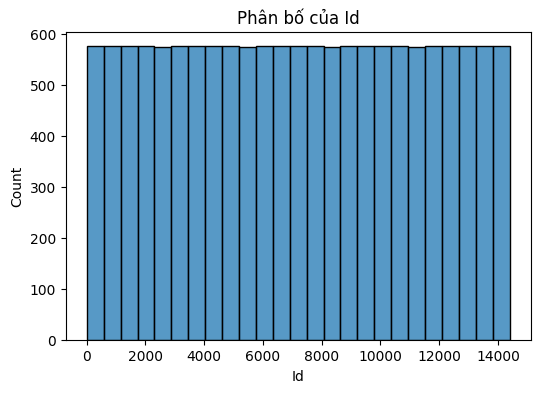

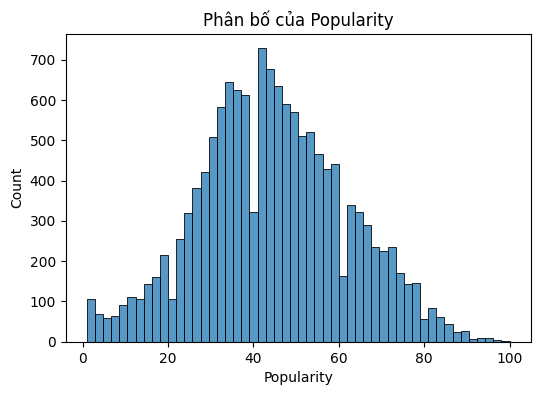

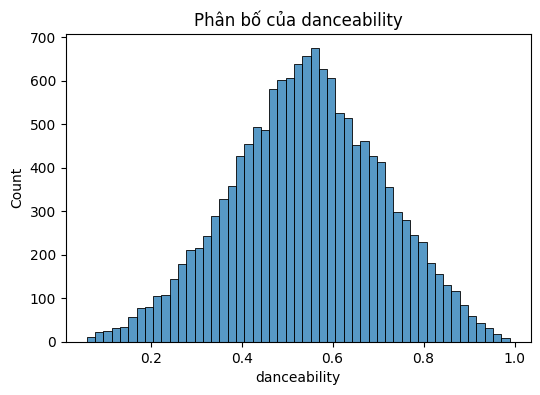

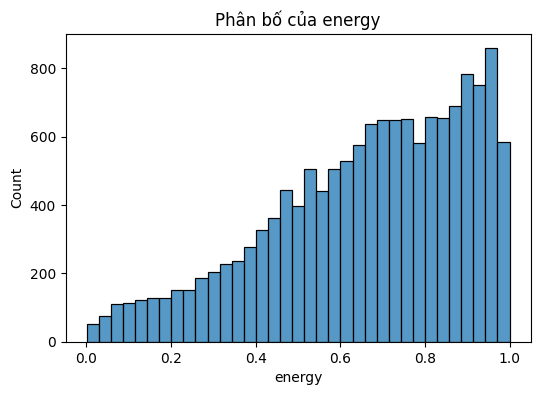

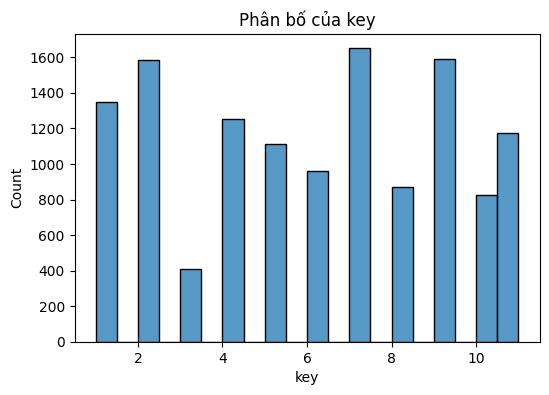

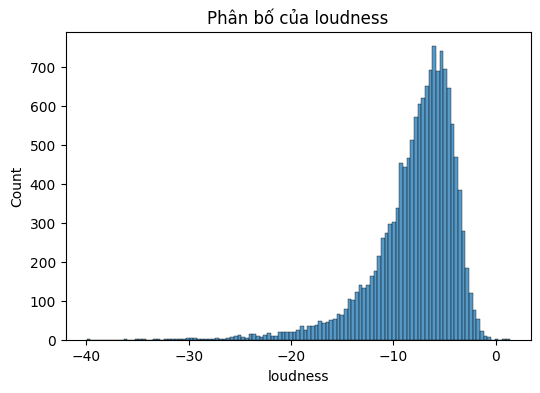

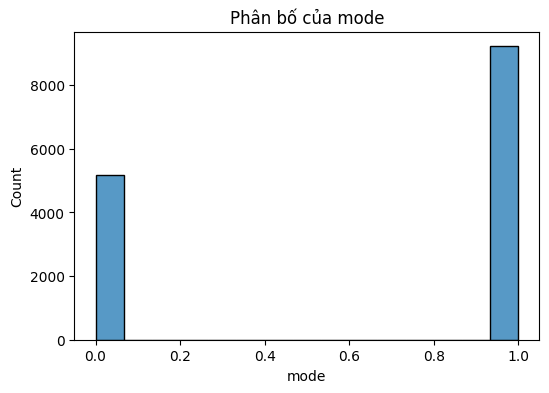

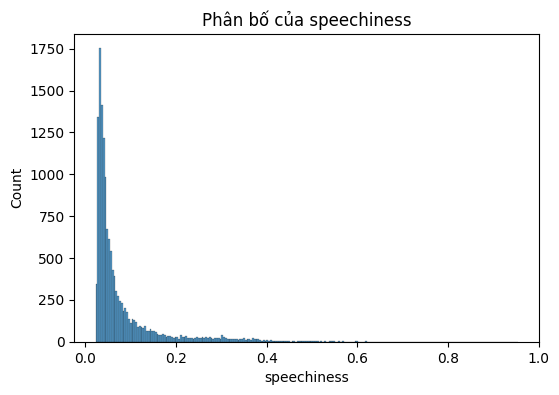

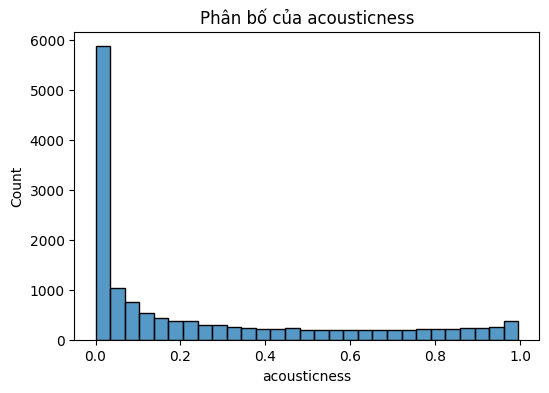

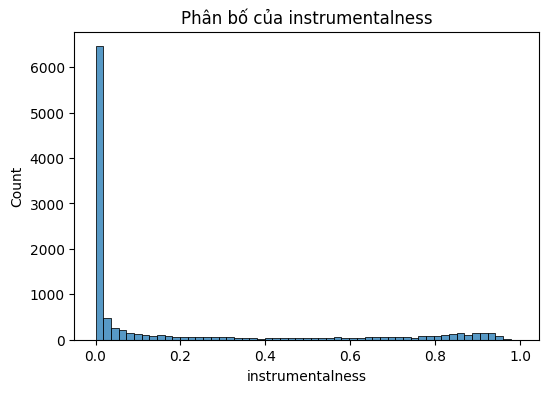

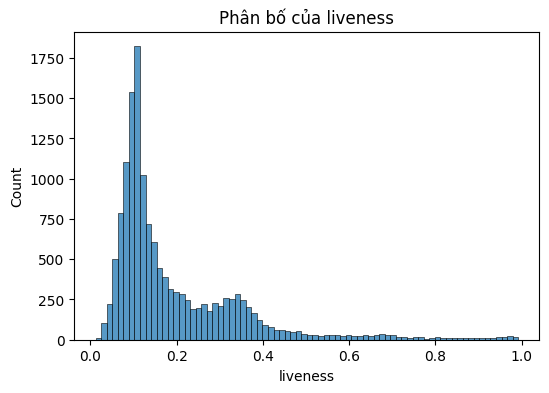

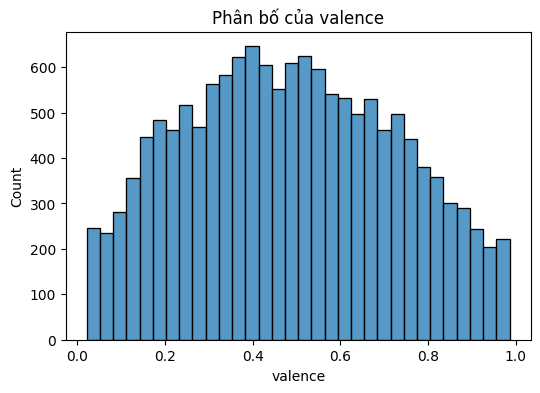

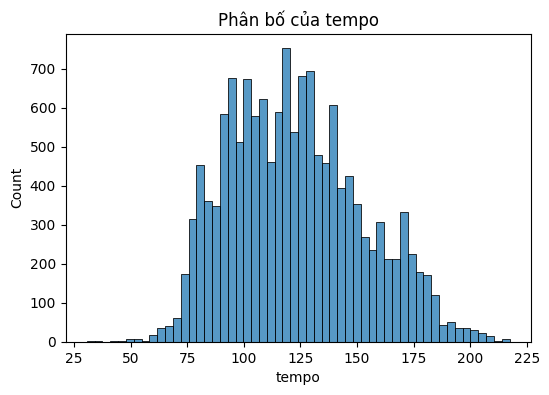

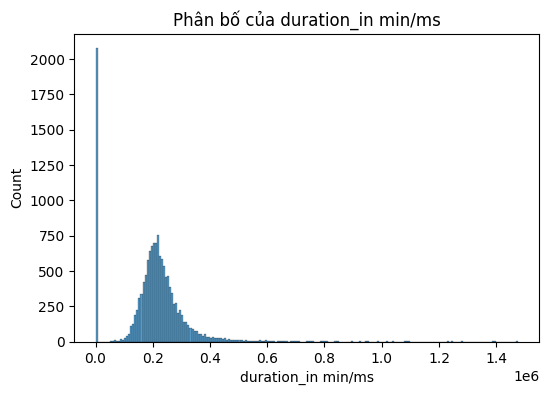

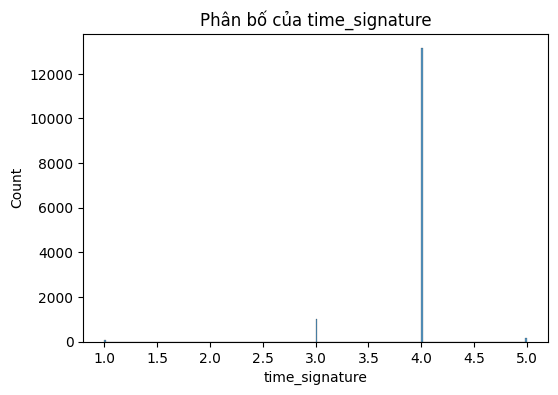

In [16]:
for cols in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(x=cols, data=df_train)
    plt.title(f"Phân bố của {cols}")
    plt.show()

**Nhận xét**:

Các đặc trưng âm thanh trong tập dữ liệu có dạng phân bố khá đa dạng:
+ Một số biến có phân bố đồng đều hoặc gần chuẩn, như danceability, energy, valence, cho thấy dữ liệu được trải đều trong khoảng 0–1 mà không có độ lệch lớn.

+ Các biến có phân bố lệch mạnh, như loudness (lệch trái do phần lớn bài hát có âm lượng âm), instrumentalness, acousticness (nhiều giá trị gần 0), phản ánh đặc trưng tự nhiên của âm thanh hiện đại — đa số bài hát có mức instrumental thấp hoặc acoustic hạn chế.

+ Một vài biến có phân bố tập trung vào một giá trị cụ thể, như mode (đa phần bằng 1), time_signature (hầu hết = 4) -> nhịp nhạc phổ biến và cấu trúc âm nhạc thống nhất trong nhiều bài hát.

+ Biến tempo và duration_in min/ms có phạm vi rộng và nhiều giá trị cực trị (outliers) -> sự khác biệt đáng kể về nhịp độ và thời lượng giữa các bài hát.

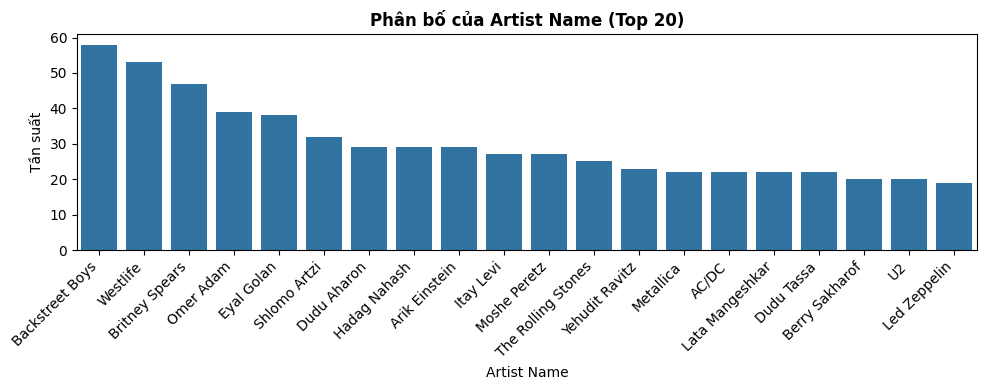

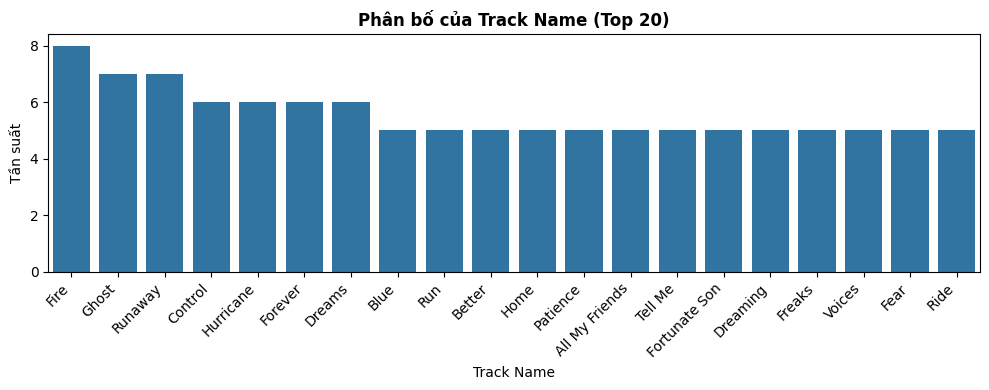

In [20]:
categorical_cols = ['Artist Name', 'Track Name']
TOP_N = 20

for col in categorical_cols:
    plt.figure(figsize=(10, 4))

    # Lấy top N giá trị
    top_values = df_train[col].value_counts().nlargest(TOP_N)

    # Tạo DataFrame tạm cho seaborn
    temp_df = pd.DataFrame({
        col: top_values.index,
        'count': top_values.values
    })

    sns.barplot(
        data=temp_df,
        x=col,
        y='count'
    )

    plt.title(f'Phân bố của {col} (Top {TOP_N})', fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel("Tần suất")

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

**Nhận xét**:
- Artist Name: Một số nghệ sĩ như Backstreet Boys, Westlife và Britney Spears xuất hiện nhiều hơn hẳn, nhưng phần lớn nghệ sĩ chỉ xuất hiện 1–2 lần. Điều này cho thấy cột này có mức độ phân tán rất cao và không mang tính phân loại rõ ràng.

- Track Name: Tên bài hát hầu như không trùng lặp — giá trị cao nhất chỉ khoảng 8 lần. Số lượng bài hát có cùng tên rất ít, cho thấy cột này cực kỳ đa dạng và khó sử dụng như một đặc trưng cho mô hình.

=> Cả hai cột phân loại đều có tính unique rất lớn và phân bố trải rộng, không phù hợp để đưa trực tiếp vào mô hình học máy.

### Trực quan hóa theo biến mục tiêu

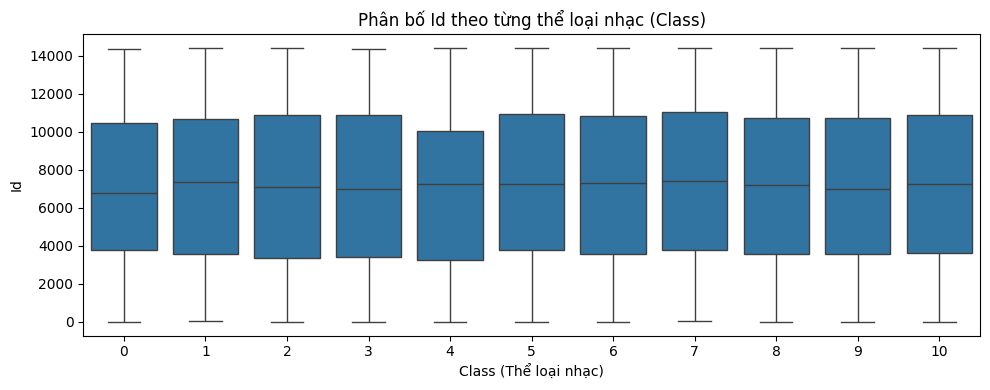

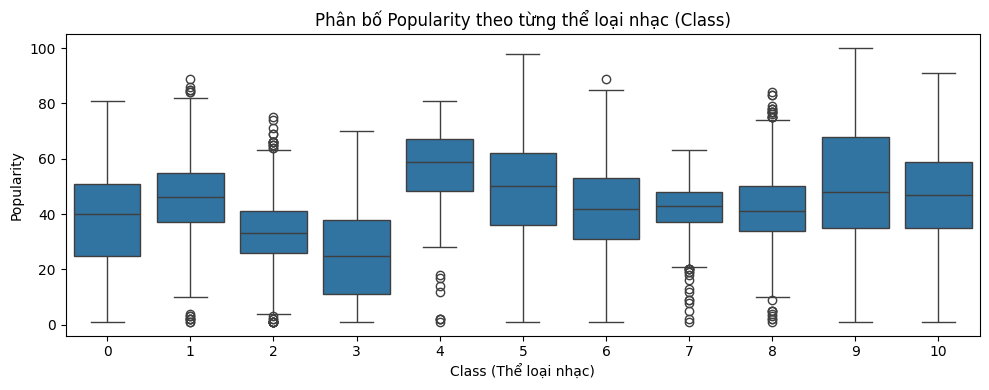

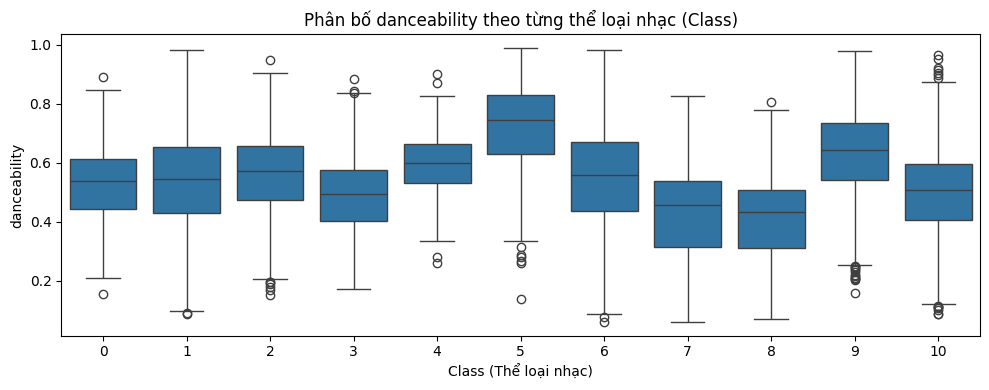

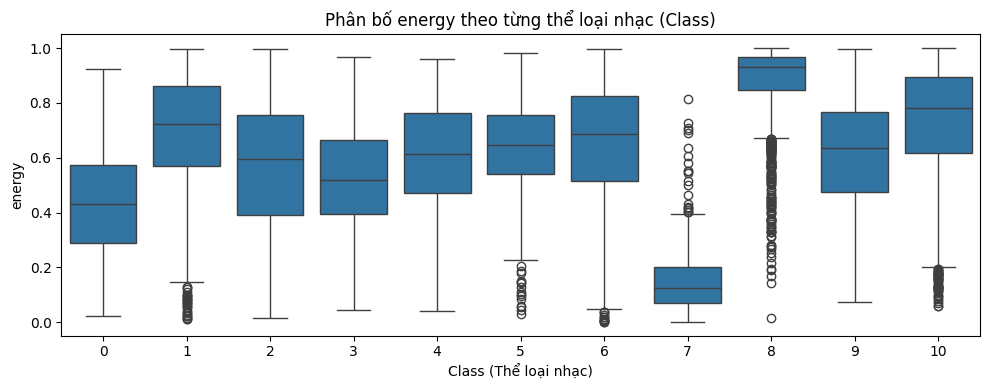

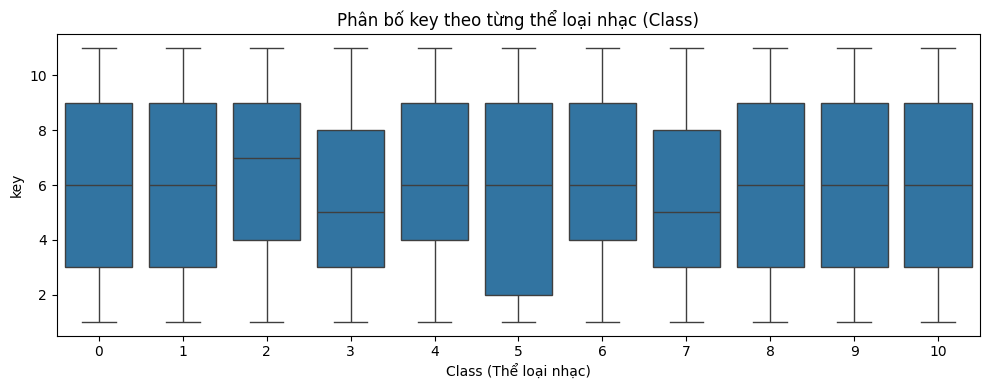

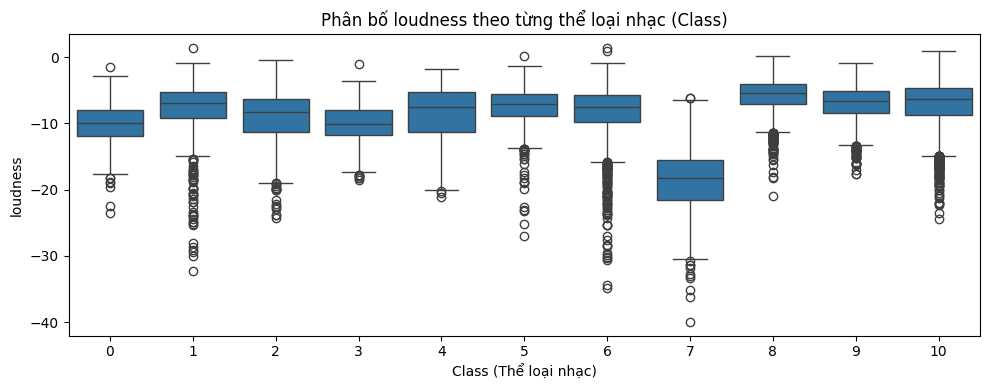

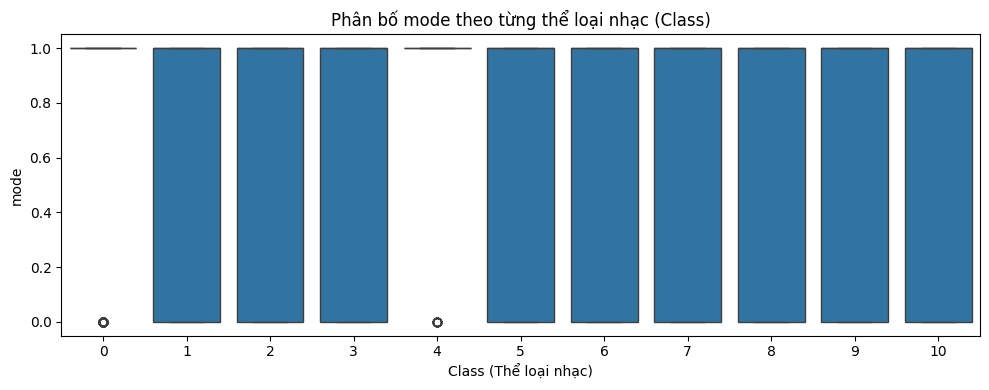

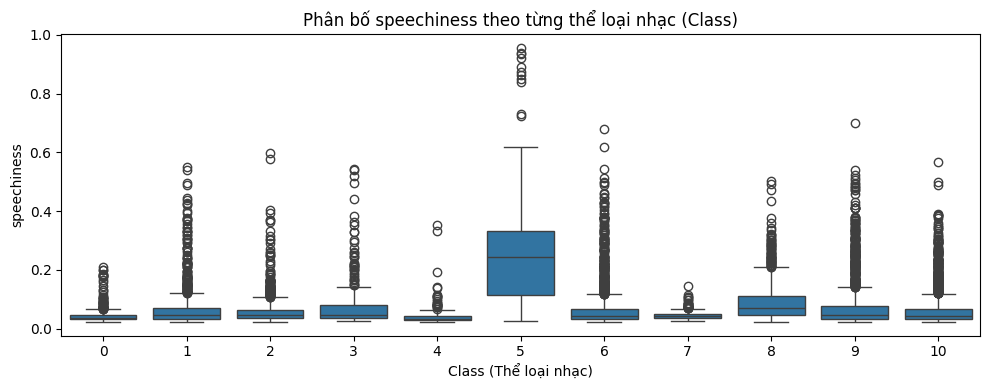

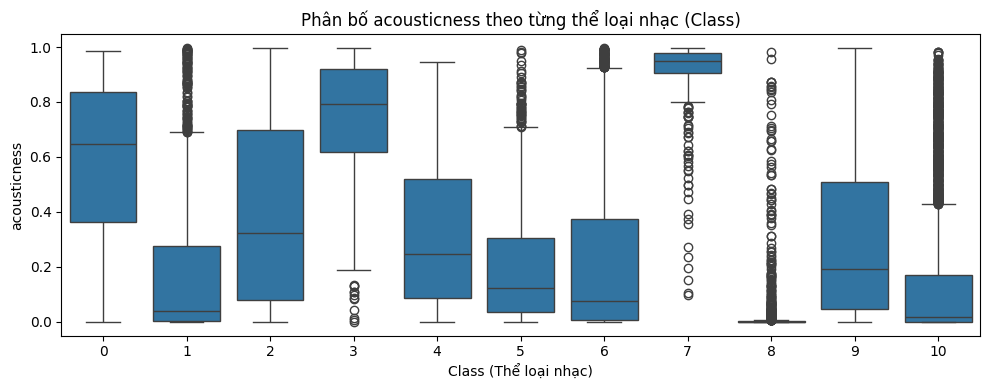

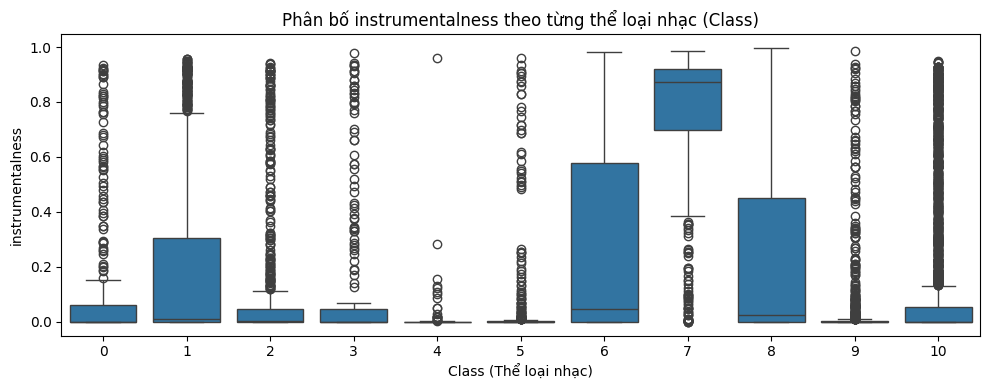

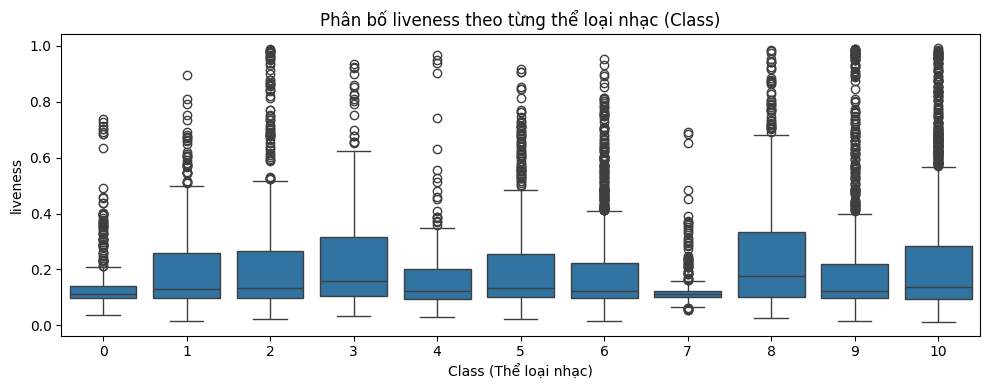

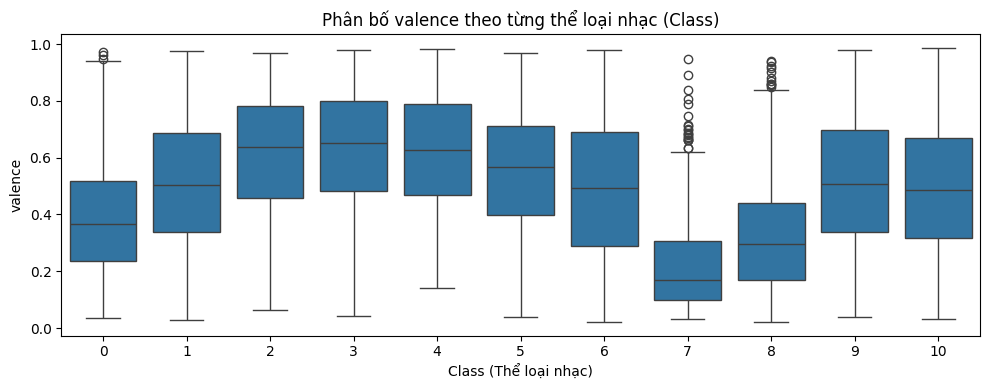

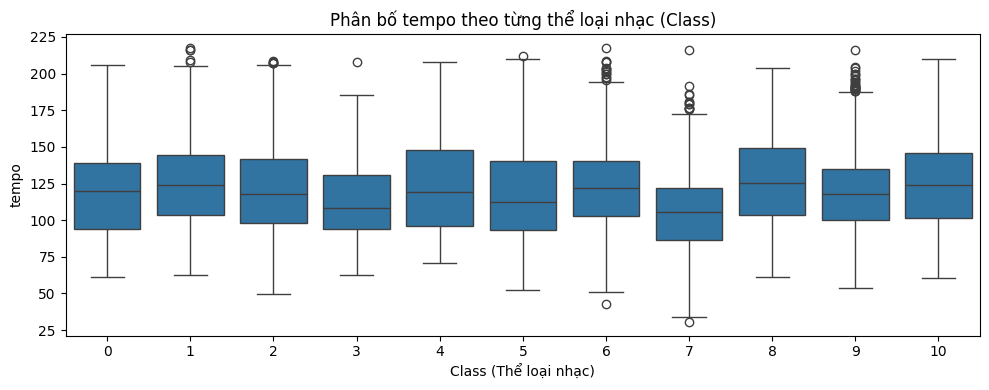

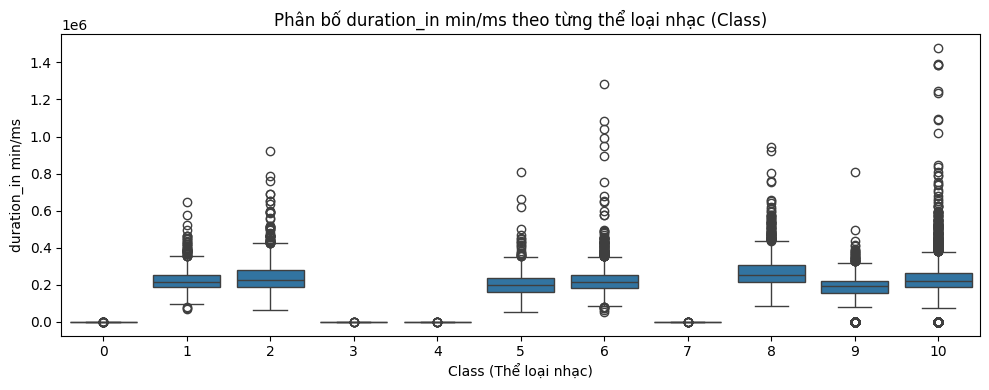

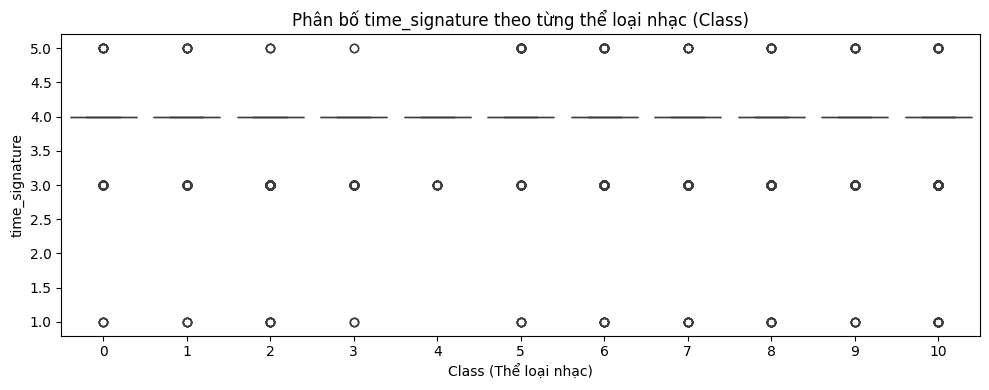

In [24]:
for cols in numeric_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df_train, x='Class', y=cols)
    plt.title(f'Phân bố {cols} theo từng thể loại nhạc (Class)', fontsize=12)
    plt.xlabel("Class (Thể loại nhạc)")
    plt.ylabel(cols)
    plt.tight_layout()
    plt.show()

**Nhận xét**:
- Nhiều đặc trưng âm thanh như danceability, energy, valence và loudness thể hiện sự khác biệt rõ rệt giữa các thể loại nhạc -> các biến này có khả năng phân biệt tốt và hữu ích cho mô hình phân loại.

- Một số thuộc tính như speechiness, acousticness, instrumentalness có phân bố lệch mạnh về phía gần 0 ở hầu hết các class, tuy ít giúp phân biệt nhưng vẫn phản ánh đặc điểm chung của nhiều bài hát hiện đại.

- Các biến như mode và time_signature gần như giống nhau giữa các class -> đây là những đặc trưng có tính phân loại thấp.

- tempo và duration_in min/ms có độ biến thiên lớn và nhiều giá trị cực trị, thể hiện sự đa dạng mạnh về nhịp độ và độ dài giữa các bài hát, mặc dù sự tách biệt theo class không quá rõ.

=> Nhìn chung, việc phân phối theo biến mục tiêu cho thấy dữ liệu không hoàn toàn đồng nhất giữa các class: một số đặc trưng có khả năng hỗ trợ mô hình phân loại tốt, trong khi một số khác có ảnh hưởng thấp và có thể cân nhắc giảm trọng số hoặc loại bỏ khi xây dựng mô hình.

### Tương quan giữa các biến số với SalePrice

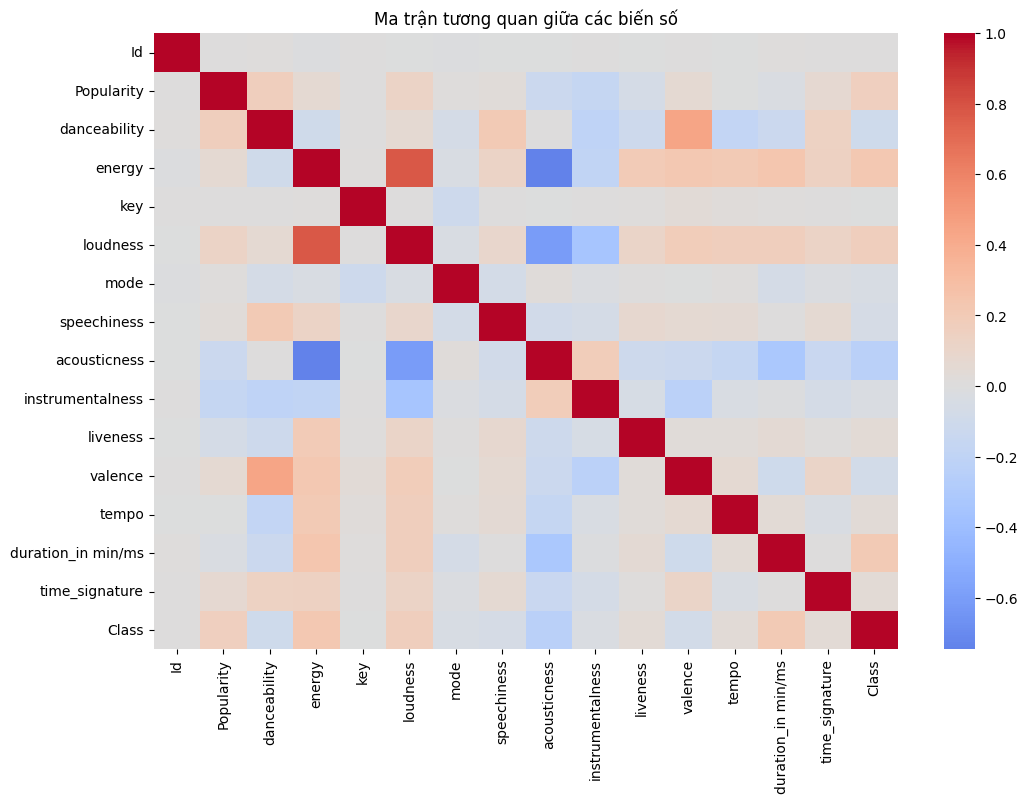

In [25]:
corr = df_train.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

**Nhận xét**:
- Ma trận tương quan cho thấy đa số các cặp biến trong tập dữ liệu có tương quan yếu, thể hiện qua màu xám nhạt. Điều này cho thấy mỗi đặc trưng âm thanh mô tả một khía cạnh khác nhau và không bị trùng lặp thông tin quá nhiều.

- energy và loudness có tương quan dương cao nhất (màu đỏ đậm), phù hợp với thực tế: bài hát có năng lượng cao thường có mức âm lượng lớn.

- acousticness và energy có tương quan âm khá mạnh (màu xanh đậm), nghĩa là các bài acoustic thường có mức năng lượng thấp.

- instrumentalness, acousticness và speechiness có tương quan âm nhẹ với nhiều biến khác (vùng xanh nhạt), cho thấy các đặc trưng này mang tính độc lập cao.

- Các biến như tempo, time_signature và liveness có tương quan rất thấp với hầu hết các biến còn lại -> khá độc lập và không chịu ảnh hưởng bởi các đặc trưng khác.

- Biến mục tiêu Class có tương quan thấp với tất cả các đặc trưng, cho thấy ranh giới giữa các thể loại nhạc không mang tính tuyến tính theo các đặc trưng âm thanh đơn lẻ — đây là lý do các mô hình phi tuyến như Random Forest, XGBoost hoặc Neural Networks phù hợp hơn.

### Phát hiện giá trị ngoại lai (Outlier)

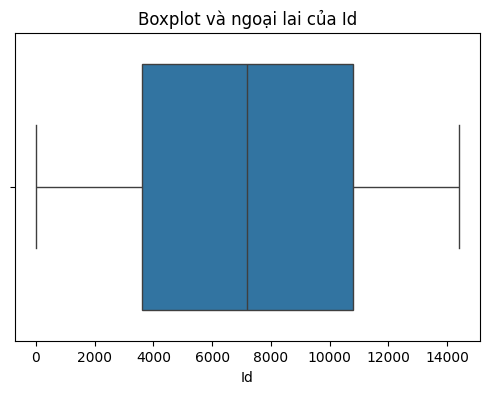

Id: số lượng ngoại lai = 0
--------------------------------------


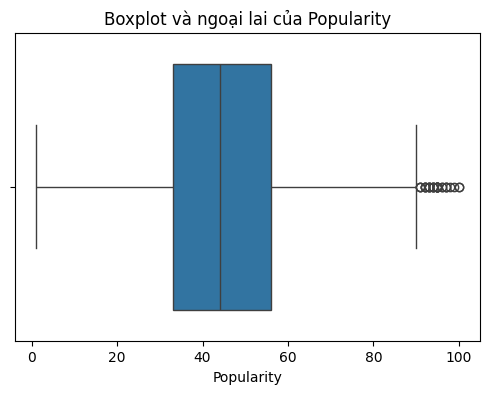

Popularity: số lượng ngoại lai = 32
--------------------------------------


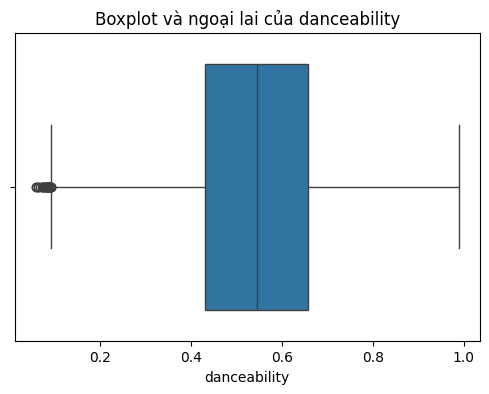

danceability: số lượng ngoại lai = 29
--------------------------------------


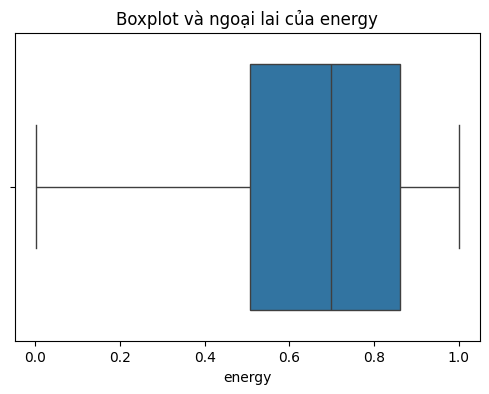

energy: số lượng ngoại lai = 0
--------------------------------------


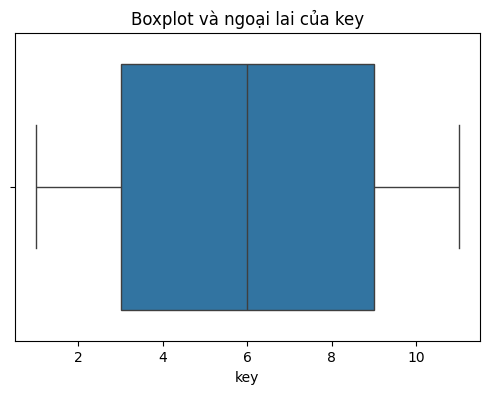

key: số lượng ngoại lai = 0
--------------------------------------


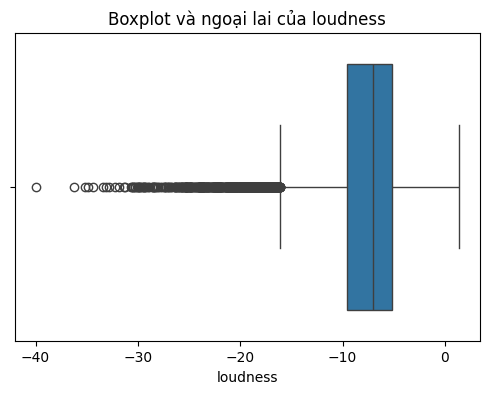

loudness: số lượng ngoại lai = 648
--------------------------------------


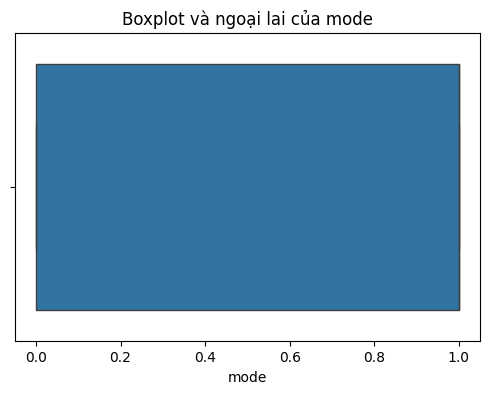

mode: số lượng ngoại lai = 0
--------------------------------------


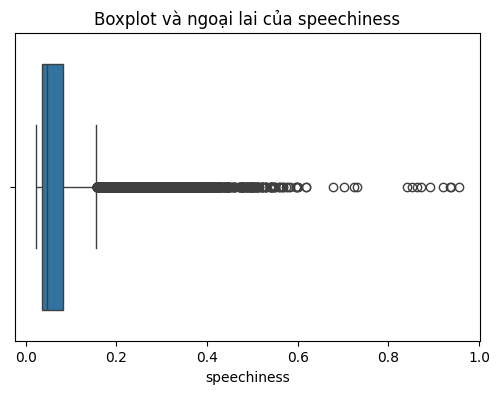

speechiness: số lượng ngoại lai = 1633
--------------------------------------


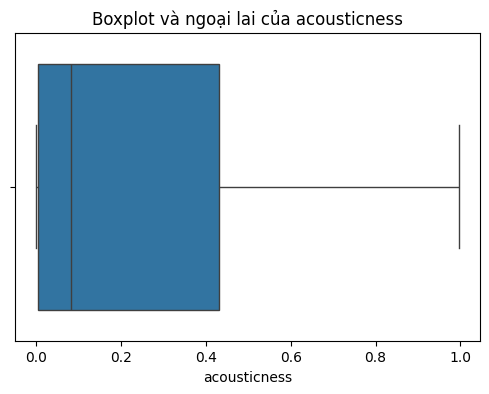

acousticness: số lượng ngoại lai = 0
--------------------------------------


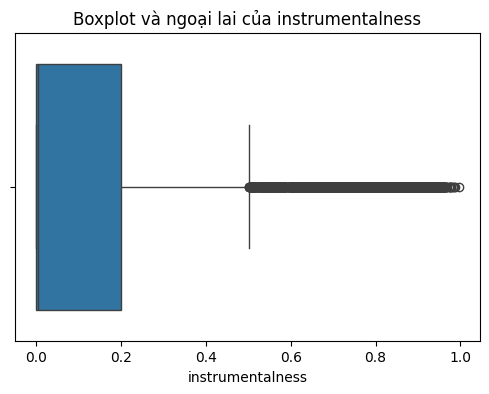

instrumentalness: số lượng ngoại lai = 1940
--------------------------------------


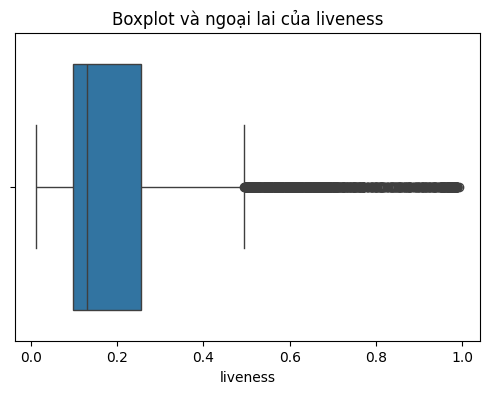

liveness: số lượng ngoại lai = 767
--------------------------------------


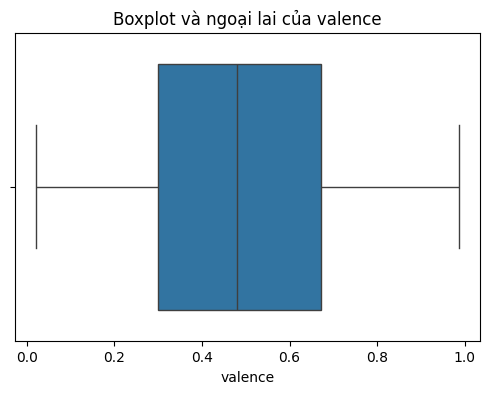

valence: số lượng ngoại lai = 0
--------------------------------------


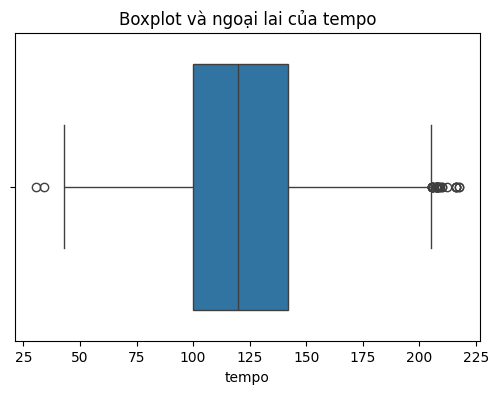

tempo: số lượng ngoại lai = 32
--------------------------------------


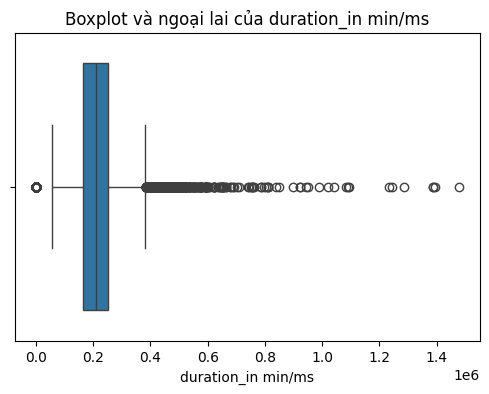

duration_in min/ms: số lượng ngoại lai = 2583
--------------------------------------


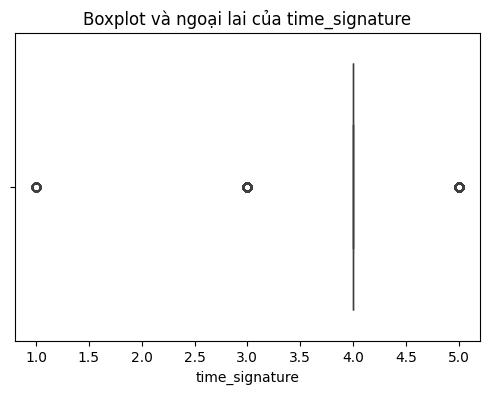

time_signature: số lượng ngoại lai = 1247
--------------------------------------


In [ ]:
# Hàm phát hiện ngoại lai theo IQR
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_train[col])
    plt.title(f"Boxplot và ngoại lai của {col}")
    plt.show()
    
    outliers = detect_outliers_iqr(df_train[col].dropna())
    print(f"{col}: số lượng ngoại lai = {len(outliers)}")
    print("--------------------------------------")

**Nhận xét**:
- Một số đặc trưng âm thanh như loudness, tempo, duration_in min/ms và instrumentalness chứa khá nhiều giá trị ngoại lai -> phản ánh sự khác biệt mạnh giữa các bài hát về âm lượng, nhịp độ, thời lượng và mức độ instrumental.

- Các đặc trưng như danceability, energy, valence, liveness có rất ít ngoại lai do các giá trị được giới hạn trong khoảng 0–1 và phân bố ổn định hơn.

- Đặc biệt, duration_in min/ms có số lượng ngoại lai lớn và biên độ trải rộng, cho thấy tồn tại các bài hát có thời lượng quá dài hoặc quá ngắn so với mặt bằng chung.

- Một số ngoại lai âm lượng (loudness) với giá trị quá thấp (tới -40 dB) hoặc quá cao có thể là kết quả của các bản thu bất thường hoặc lỗi trong quá trình thu âm.

## 4. Kết luận & Insight

- Các biến phân biệt tốt nhất giữa các thể loại nhạc: danceability, energy, loudness, valence, instrumentalness.

- Biến mục tiêu Class bị mất cân bằng → cần xử lý imbalance trước khi huấn luyện mô hình.

- Một số biến có nhiều missing values (key, instrumentalness, Popularity) cần được xử lý.

- Một số outlier xuất hiện ở loudness, tempo, duration_in min/ms, có thể xem xét chuẩn hóa hoặc giảm ảnh hưởng ngoại lai.